In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from matplotlib.pyplot import axes, title
import numpy as np

In [15]:
# Load the data set
df = pd.read_csv("data_tunis.csv")

In [16]:
df.head()

,date,Tmin,Tmax,vent,pluie
0,01/01/2010,12.0,19.0,50.0,0.0
1,02/01/2010,12.0,17.0,35.0,2.7
2,03/01/2010,11.0,18.0,15.0,0.5
3,04/01/2010,9.0,19.0,13.0,0.0
4,05/01/2010,8.0,23.0,16.0,0.0


In [17]:
df.tail()

,date,Tmin,Tmax,vent,pluie
2917,27/12/2017,-5.0,17.0,29.0,0.0
2918,28/12/2017,9.0,13.0,28.0,3.5
2919,29/12/2017,10.0,15.0,39.0,6.3
2920,30/12/2017,NaN,NaN,NaN,NaN
2921,31/12/2017,NaN,NaN,NaN,NaN


In [18]:
# Fill some null values
df = df.bfill(axis=0)

In [19]:
# Remove null acquisations
df = df.dropna()

,date,Tmin,Tmax,vent,pluie
0,01/01/2010,12.0,19.0,50.0,0.0
1,02/01/2010,12.0,17.0,35.0,2.7
2,03/01/2010,11.0,18.0,15.0,0.5
3,04/01/2010,9.0,19.0,13.0,0.0
4,05/01/2010,8.0,23.0,16.0,0.0
...,...,...,...,...,...
2915,25/12/2017,-2.0,18.0,15.0,0.2
2916,26/12/2017,6.0,17.0,29.0,0.0
2917,27/12/2017,-5.0,17.0,29.0,0.0
2918,28/12/2017,9.0,13.0,28.0,3.5


In [21]:
# Replace min_temp and max_temp with avg_temp
df['temp'] = (df['Tmin'] + df['Tmax']) / 2
df = df.drop('Tmin',axis=1)
df = df.drop('Tmax',axis=1)

df

,date,vent,pluie,temp
0,01/01/2010,50.0,0.0,15.5
1,02/01/2010,35.0,2.7,14.5
2,03/01/2010,15.0,0.5,14.5
3,04/01/2010,13.0,0.0,14.0
4,05/01/2010,16.0,0.0,15.5
...,...,...,...,...
2915,25/12/2017,15.0,0.2,8.0
2916,26/12/2017,29.0,0.0,11.5
2917,27/12/2017,29.0,0.0,6.0
2918,28/12/2017,28.0,3.5,11.0


In [22]:
# Create empty dataframes for each month
df_jan = pd.DataFrame(columns=df.columns)
df_feb = pd.DataFrame(columns=df.columns)
df_mar = pd.DataFrame(columns=df.columns)
df_apr = pd.DataFrame(columns=df.columns)
df_may = pd.DataFrame(columns=df.columns)
df_jun = pd.DataFrame(columns=df.columns)
df_jul = pd.DataFrame(columns=df.columns)
df_aug = pd.DataFrame(columns=df.columns)
df_sep = pd.DataFrame(columns=df.columns)
df_oct = pd.DataFrame(columns=df.columns)
df_nov = pd.DataFrame(columns=df.columns)
df_dec = pd.DataFrame(columns=df.columns)

In [24]:
# Fill the dataframes of each month

for i in range(len(df)):

    if df.loc[i]['date'][3:5] == '01':
        df_jan = pd.concat([df_jan, df.loc[[i]]], ignore_index=True)

    if df.loc[i]['date'][3:5] == '02':
        df_feb = pd.concat([df_feb, df.loc[[i]]], ignore_index=True)

    if df.loc[i]['date'][3:5] == '03':
        df_mar = pd.concat([df_mar, df.loc[[i]]], ignore_index=True)

    if df.loc[i]['date'][3:5] == '04':
        df_apr = pd.concat([df_apr, df.loc[[i]]], ignore_index=True)

    if df.loc[i]['date'][3:5] == '05':
        df_may = pd.concat([df_may, df.loc[[i]]], ignore_index=True)

    if df.loc[i]['date'][3:5] == '06':
        df_jun = pd.concat([df_jun, df.loc[[i]]], ignore_index=True)

    if df.loc[i]['date'][3:5] == '07':
        df_jul = pd.concat([df_jul, df.loc[[i]]], ignore_index=True)

    if df.loc[i]['date'][3:5] == '08':
        df_aug = pd.concat([df_aug, df.loc[[i]]], ignore_index=True)

    if df.loc[i]['date'][3:5] == '09':
        df_sep = pd.concat([df_sep, df.loc[[i]]], ignore_index=True)

    if df.loc[i]['date'][3:5] == '10':
        df_oct = pd.concat([df_oct, df.loc[[i]]], ignore_index=True)

    if df.loc[i]['date'][3:5] == '11':
        df_nov = pd.concat([df_nov, df.loc[[i]]], ignore_index=True)

    if df.loc[i]['date'][3:5] == '12':
        df_dec = pd.concat([df_dec, df.loc[[i]]], ignore_index=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_1592\2000912665.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_jan = pd.concat([df_jan, df.loc[[i]]], ignore_index=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_1592\2000912665.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_feb = pd.concat([df_feb, df.loc[[i]]], ignore_index=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_1592\2000912665.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecate

In [25]:
# Choose a month to work with; for example: January
df_curr = df_jan

# Remove the columns 'date' and 'index'
df_curr = df_curr.reset_index().drop(['date','index'],axis=1)

# Get xdata, ydata and zdata to make 3D plot later on
xdata = df_curr['vent']
ydata = df_curr['pluie']
zdata = df_curr['temp']

In [27]:
# Fill the dataframe of reference points
for i in range(len(df_curr)):
    if (df_curr.loc[i, 'pluie'] > MAX_PLUIE 
        or df_curr.loc[i, 'vent'] > MAX_VENT 
        or df_curr.loc[i, 'temp'] > MAX_TEMP 
        or df_curr.loc[i, 'temp'] < MIN_TEMP):

        df_anomaly_reference = pd.concat(
            [df_anomaly_reference, df_curr.loc[[i]]],
            ignore_index=True
        )

print("The number of anomalies reference is: " + str(len(df_anomaly_reference)))

The number of anomalies reference is: 6


C:\Users\HP\AppData\Local\Temp\ipykernel_1592\3298360809.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_anomaly_reference = pd.concat(


C:\Users\HP\AppData\Local\Temp\ipykernel_1592\2361808147.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Set1')
C:\Users\HP\AppData\Local\Temp\ipykernel_1592\2361808147.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Set1')


<Axes: xlabel='temp', ylabel='pluie'>

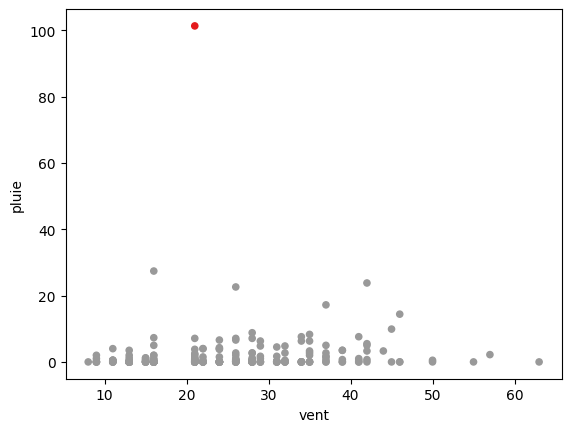

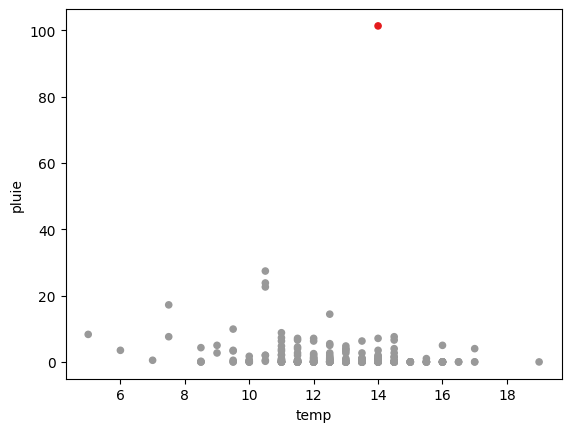

In [28]:
# 1st algorithm: DBSCAN
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler() 
outlier_detection = DBSCAN(eps = .2, metric="euclidean", min_samples = 5, n_jobs = -1)
num2 = scaler.fit_transform(df_curr)
num2 = pd.DataFrame(num2, columns = df_curr.columns)
clusters = outlier_detection.fit_predict(num2)

# 2D Plot: pluie = f(vent)
from matplotlib import cm
cmap = cm.get_cmap('Set1')
df_curr.plot.scatter(x='vent',y='pluie', c=clusters, cmap=cmap, colorbar = False)

# 2D Plot: pluie = f(temp)
from matplotlib import cm
cmap = cm.get_cmap('Set1')
df_curr.plot.scatter(x='temp',y='pluie', c=clusters, cmap=cmap, colorbar = False)

# PS: This will be the only time that we show 2D plots

DBSCAN  | True Negative = 0


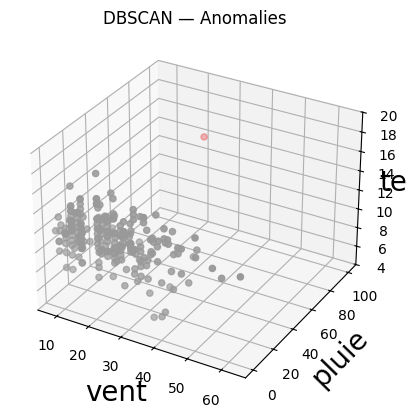

In [29]:
# 3D Plot: pluie = f(temp, vent)
ax = axes(projection='3d')
ax.scatter3D(xdata, ydata, zdata, c=clusters, cmap=cmap)
ax.set_xlabel('vent',fontsize=20)
ax.set_ylabel('pluie',fontsize=20)
ax.set_zlabel('temp',fontsize=20)
title('DBSCAN — Anomalies')

true_predicted = 0
mistakes = 0

# Get True Negative and False Positive 
for i in range(len(clusters)):
    if clusters[i] == -1 and i in df_anomaly_reference.index:
        true_predicted += 1
    if clusters[i] == -1 and i not in df_anomaly_reference.index:
        mistakes += 1

print("DBSCAN  | True Negative = " + str(true_predicted))

Isolation Forests | True Negative = 0
Isolation Forests | False Positive = 3


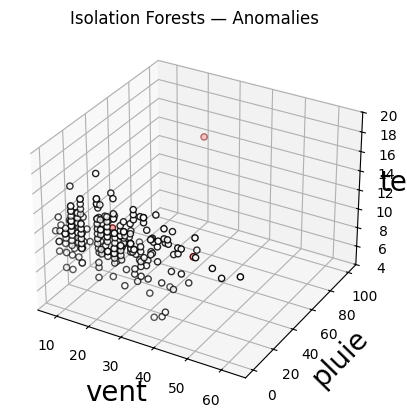

In [30]:
# 2nd algorithm: Isolation Forests
from sklearn.ensemble import IsolationForest
rs=np.random.RandomState(0)
clf = IsolationForest(max_samples=100,random_state=rs, contamination=.01) 
clf.fit(df_curr)
if_scores = clf.decision_function(df_curr)
if_anomalies=clf.predict(df_curr)
if_anomalies=pd.Series(if_anomalies).replace([-1,1],[1,0])
if_anomalies=df_curr[if_anomalies==1]

# 3D Plot
ax = plt.axes(projection='3d')
ax.scatter3D(xdata, ydata, zdata, c='white',s=20,edgecolor='k')
ax.scatter3D(if_anomalies['vent'], if_anomalies['pluie'], if_anomalies['temp'], c='red')
ax.set_xlabel('vent',fontsize=20)
ax.set_ylabel('pluie',fontsize=20)
ax.set_zlabel('temp',fontsize=20)
plt.title('Isolation Forests — Anomalies')

true_predicted = 0
mistakes = 0

# Get True Negative and False Positive 
for i in range(len(clusters)):
    if i in if_anomalies.index and i in df_anomaly_reference.index:
        true_predicted += 1
    if i in if_anomalies.index and i not in df_anomaly_reference.index:
        mistakes += 1

print("Isolation Forests | True Negative = " + str(true_predicted))
print("Isolation Forests | False Positive = " + str(mistakes))

Local Outlier Factor | True Negative = 0
Local Outlier Factor | False Positive = 3


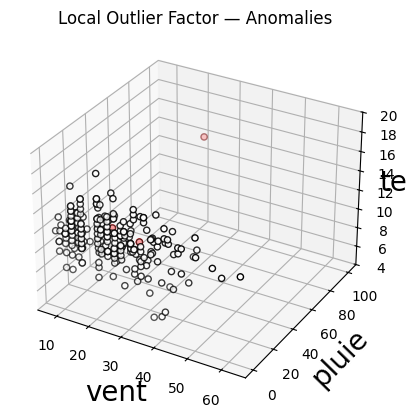

In [32]:
# 3rd algorithm: Local Outlier Factor
from sklearn.neighbors import LocalOutlierFactor
clf = LocalOutlierFactor(n_neighbors=30, contamination=.01)
y_pred = clf.fit_predict(df_curr)
LOF_Scores = clf.negative_outlier_factor_
LOF_pred=pd.Series(y_pred).replace([-1,1],[1,0])
LOF_anomalies=df_curr[LOF_pred==1]

# 3D Plot
ax = plt.axes(projection='3d')
ax.scatter3D(xdata, ydata, zdata, c='white',s=20,edgecolor='k')
ax.scatter3D(LOF_anomalies['vent'], LOF_anomalies['pluie'], LOF_anomalies['temp'], c='red')
ax.set_xlabel('vent',fontsize=20)
ax.set_ylabel('pluie',fontsize=20)
ax.set_zlabel('temp',fontsize=20)
plt.title('Local Outlier Factor — Anomalies')

true_predicted = 0
mistakes = 0

# Get True Negative and False Positive 
for i in range(len(clusters)):
    if i in LOF_anomalies.index and i in df_anomaly_reference.index:
        true_predicted += 1
    if i in LOF_anomalies.index and i not in df_anomaly_reference.index:
        mistakes += 1

print("Local Outlier Factor | True Negative = " + str(true_predicted))
print("Local Outlier Factor | False Positive = " + str(mistakes))

Elliptic Envelope | True Negative = 0
Elliptic Envelope | False Positive = 2


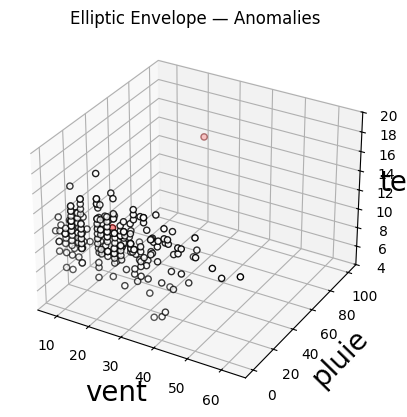

In [33]:
# 4th algorithm: Elliptic Envelope
from sklearn.covariance import EllipticEnvelope
clf = EllipticEnvelope(contamination=0.005,random_state=0)
clf.fit(df_curr)
ee_scores = pd.Series(clf.decision_function(df_curr)) 
ee_pred = clf.predict(df_curr)
ee_anomalies = df_curr[ee_pred==-1]

# 3D Plot
ax = plt.axes(projection='3d')
ax.scatter3D(xdata, ydata, zdata, c='white',s=20,edgecolor='k')
ax.scatter3D(ee_anomalies['vent'], ee_anomalies['pluie'], ee_anomalies['temp'], c='red')
ax.set_xlabel('vent',fontsize=20)
ax.set_ylabel('pluie',fontsize=20)
ax.set_zlabel('temp',fontsize=20)
plt.title('Elliptic Envelope — Anomalies')

true_predicted = 0
mistakes = 0

# Get True Negative and False Positive 
for i in range(len(clusters)):
    if i in ee_anomalies.index and i in df_anomaly_reference.index:
        true_predicted += 1
    if i in ee_anomalies.index and i not in df_anomaly_reference.index:
        mistakes += 1

print("Elliptic Envelope | True Negative = " + str(true_predicted))
print("Elliptic Envelope | False Positive = " + str(mistakes))

One-Class Support Vector Machines | True Negative = 0
One-Class Support Vector Machines | False Positive = 9


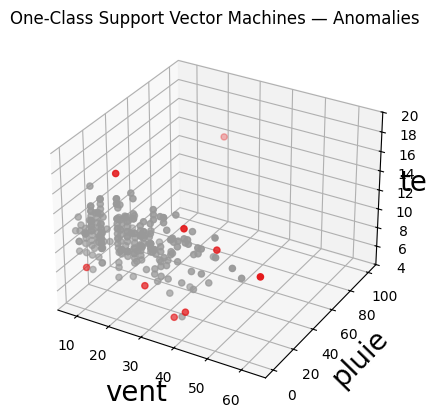

In [34]:
# 5th algorithm: One-Class Support Vector Machines
from sklearn import svm
clf=svm.OneClassSVM(nu=.02,kernel='rbf',gamma=.005)
clf.fit(df_curr)
y_pred=clf.predict(df_curr)

# 3D Plot
ax = plt.axes(projection='3d')
ax.scatter3D(xdata, ydata, zdata, c=y_pred, cmap=cmap)
ax.set_xlabel('vent',fontsize=20)
ax.set_ylabel('pluie',fontsize=20)
ax.set_zlabel('temp',fontsize=20)
plt.title('One-Class Support Vector Machines — Anomalies')

true_predicted = 0
mistakes = 0

# Get True Negative and False Positive 
for i in range(len(clusters)):
    if y_pred[i] == -1 and i in df_anomaly_reference.index:
        true_predicted += 1
    if y_pred[i] == -1 and i not in df_anomaly_reference.index:
        mistakes += 1

print("One-Class Support Vector Machines | True Negative = " + str(true_predicted))
print("One-Class Support Vector Machines | False Positive = " + str(mistakes))

In [35]:
def evaluate_anomaly_model(y_true, y_pred):

    TP = np.sum((y_true == 1) & (y_pred == 1))
    FP = np.sum((y_true == 0) & (y_pred == 1))

    total_anomalies = np.sum(y_true == 1)

    detection_rate = (TP / total_anomalies) * 100

    return TP, detection_rate, FP

In [39]:
# ============================================================
# COMPARISON OF ALL 5 ANOMALY DETECTION ALGORITHMS
# ============================================================

# Total number of reference anomalies
total_anomalies = len(df_anomaly_reference)

print("Total reference anomalies:", total_anomalies)
print()


# ------------------------------------------------------------
# 1. DBSCAN
# ------------------------------------------------------------

dbscan_tp = 0
dbscan_fp = 0

for i in range(len(clusters)):

    # DBSCAN -1 means anomaly
    if clusters[i] == -1 and i in df_anomaly_reference.index:
        dbscan_tp += 1

    if clusters[i] == -1 and i not in df_anomaly_reference.index:
        dbscan_fp += 1

dbscan_percentage = (dbscan_tp / total_anomalies) * 100


# ------------------------------------------------------------
# 2. Isolation Forest
# ------------------------------------------------------------

if_tp = 0
if_fp = 0

for i in range(len(df_curr)):

    if i in if_anomalies.index and i in df_anomaly_reference.index:
        if_tp += 1

    if i in if_anomalies.index and i not in df_anomaly_reference.index:
        if_fp += 1

if_percentage = (if_tp / total_anomalies) * 100


# ------------------------------------------------------------
# 3. LOF
# ------------------------------------------------------------

lof_tp = 0
lof_fp = 0

for i in range(len(df_curr)):

    if i in LOF_anomalies.index and i in df_anomaly_reference.index:
        lof_tp += 1

    if i in LOF_anomalies.index and i not in df_anomaly_reference.index:
        lof_fp += 1

lof_percentage = (lof_tp / total_anomalies) * 100


# ------------------------------------------------------------
# 4. Elliptic Envelope
# ------------------------------------------------------------

ee_tp = 0
ee_fp = 0

for i in range(len(df_curr)):

    if i in ee_anomalies.index and i in df_anomaly_reference.index:
        ee_tp += 1

    if i in ee_anomalies.index and i not in df_anomaly_reference.index:
        ee_fp += 1

ee_percentage = (ee_tp / total_anomalies) * 100


# ------------------------------------------------------------
# 5. One-Class SVM
# ------------------------------------------------------------

svm_tp = 0
svm_fp = 0

for i in range(len(y_pred)):

    # -1 = anomaly
    if y_pred[i] == -1 and i in df_anomaly_reference.index:
        svm_tp += 1

    if y_pred[i] == -1 and i not in df_anomaly_reference.index:
        svm_fp += 1

svm_percentage = (svm_tp / total_anomalies) * 100


# ============================================================
# FINAL COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({

    'Algorithm': [
        'DBSCAN',
        'Isolation Forest',
        'LOF',
        'Elliptic Envelope',
        'One-Class SVM'
    ],

    'TP': [
        dbscan_tp,
        if_tp,
        lof_tp,
        ee_tp,
        svm_tp
    ],

    'TP/Anomalies (%)': [
        round(dbscan_percentage, 2),
        round(if_percentage, 2),
        round(lof_percentage, 2),
        round(ee_percentage, 2),
        round(svm_percentage, 2)
    ],

    'FP': [
        dbscan_fp,
        if_fp,
        lof_fp,
        ee_fp,
        svm_fp
    ]
})


print(comparison)

Total reference anomalies: 6

           Algorithm  TP  TP/Anomalies (%)  FP
0             DBSCAN   0               0.0   1
1   Isolation Forest   0               0.0   3
2                LOF   0               0.0   3
3  Elliptic Envelope   0               0.0   2
4      One-Class SVM   0               0.0   9
